In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import rcParams

from neuralforecast.core import NeuralForecast
from neuralforecast.models import TimesNet

from neuralforecast.losses.numpy import mae, mse

import yfinance as yf
import pandas_ta as ta

In [2]:
df = yf.Ticker("VTI").history(start="2016-01-01", period='1d')
df.reset_index(inplace=True)
# Change all column headings to be lower case, and remove spacing
df.columns = [str(x).lower().replace(' ', '_') for x in df.columns]

# Get month of each sample
df['month'] = df.date.dt.month # type: ignore

df['ds'] = df['date'].dt.tz_localize(None) # type: ignore
df['unique_id'] = 'OT'
df['y'] = df['close']
df.drop(columns=['dividends', 'stock_splits', 'capital_gains', 'date'], inplace=True)

In [3]:
df.head()

,open,high,low,close,volume,month,ds,unique_id,y
0,87.259903,87.574640,86.409251,87.396004,6138300,1,2016-01-04,OT,87.396004
1,87.532137,87.770319,87.021747,87.591682,3652300,1,2016-01-05,OT,87.591682
2,86.366710,86.962171,85.873331,86.417747,3732800,1,2016-01-06,OT,86.417747
3,84.980200,85.745788,84.104029,84.299675,9256200,1,2016-01-07,OT,84.299675
4,84.733486,85.056732,83.176791,83.338417,7015800,1,2016-01-08,OT,83.338417


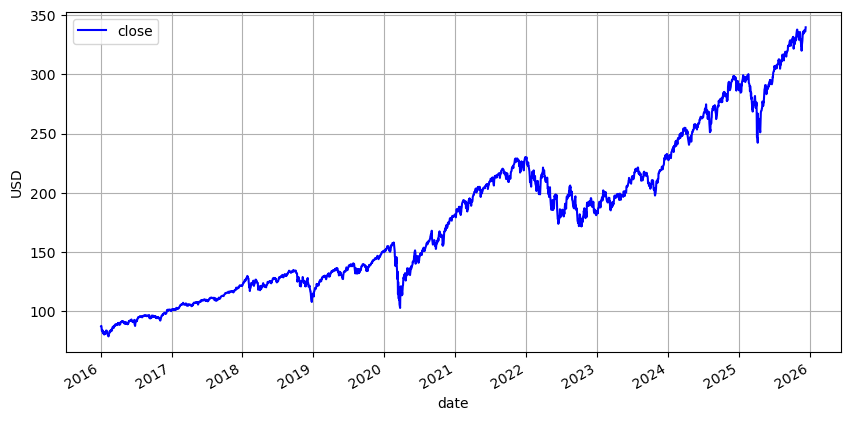

In [4]:
# Plot adjusted close over time
rcParams['figure.figsize'] = 10, 5 # width 10, height 8

ax = df.plot(x='ds', y='close', style='b-', grid=True)
ax.set_xlabel("date")
ax.set_ylabel("USD")
plt.show()

In [5]:
# Разделение данных на train и test
split_date = '2025-01-01'
df_train = df[df['ds'] < split_date].copy()
df_test = df[df['ds'] >= split_date].copy()

print(f"Train data: {df_train['ds'].min()} to {df_train['ds'].max()}")
print(f"Test data: {df_test['ds'].min()} to {df_test['ds'].max()}")
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")

Train data: 2016-01-04 00:00:00 to 2024-12-31 00:00:00
Test data: 2025-01-02 00:00:00 to 2025-12-11 00:00:00
Train shape: (2264, 9), Test shape: (237, 9)


In [7]:
# Модель для прогнозирования на 5 шагов вперед
horizon = 5

models = [TimesNet(h=horizon,
                input_size=2*horizon,
                max_steps=100)]

nf = NeuralForecast(models=models, freq='D')

Seed set to 1


In [8]:
# Обучение модели на train данных
nf.fit(df=df_train)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss           │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train   │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler         │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ model          │ ModuleList    │  4.7 M │ train │     0 │
│ 4 │ enc_embedding  │ DataEmbedding │    192 │ train │     0 │
│ 5 │ layer_norm     │ LayerNorm     │    128 │ train │     0 │
│ 6 │ predict_linear │ Linear        │    165 │ train │     0 │
│ 7 │ projection     │ Linear        │     65 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=100` reached.


In [9]:
# Скользящий прогноз на весь тестовый период
predictions_list = []
actual_list = []
dates_list = []

# Начинаем с train данных
current_data = df_train.copy()

# Количество итераций
test_length = len(df_test)

for i in range(0, test_length, horizon):
    # Определяем batch реальных торговых дней из test
    end_idx = min(i + horizon, test_length)
    current_test_batch = df_test.iloc[i:end_idx].copy()
    
    preds = nf.predict(df=current_data)
    preds = preds.reset_index() # pyright: ignore[reportAttributeAccessIssue]
        
    # Собираем прогнозы и реальные значения СИНХРОННО
    for j in range(len(current_test_batch)):
        if j < len(preds):
            row = current_test_batch.iloc[j]
            predictions_list.append(preds['TimesNet'].iloc[j])
            actual_list.append(row['y'])
            dates_list.append(row['ds'])
    
    # Обновляем current_data для следующей итерации
    current_data = pd.concat([current_data, current_test_batch], ignore_index=True)

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'ds': dates_list,
    'actual': actual_list,
    'predicted': predictions_list
})

print(f"Total predictions made: {len(results_df)}")
results_df.head(10)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


...

Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Output()

Total predictions made: 237


,ds,actual,predicted
0,2025-01-02,286.582336,295.138885
1,2025-01-03,290.347137,293.789276
2,2025-01-06,291.971985,290.588440
3,2025-01-07,288.712433,296.172729
4,2025-01-08,288.979889,294.137238
5,2025-01-10,284.640442,291.286682
6,2025-01-13,285.106140,291.585907
7,2025-01-14,285.750122,292.865112
8,2025-01-15,290.991119,293.696320
9,2025-01-16,290.773163,290.084137


In [10]:
# Вычисление метрик
mae_value = mae(results_df['actual'].values, results_df['predicted'].values) # type: ignore
mse_value = mse(results_df['actual'].values, results_df['predicted'].values) # type: ignore
rmse_value = np.sqrt(mse_value)

print(f"Metrics for rolling forecast ({len(results_df)} predictions):")
print(f"MAE:  {mae_value:.4f}")
print(f"MSE:  {mse_value:.4f}")
print(f"RMSE: {rmse_value:.4f}")

# Процент средней абсолютной ошибки
mape = np.mean(np.abs((results_df['actual'] - results_df['predicted']) / results_df['actual'])) * 100
print(f"MAPE: {mape:.2f}%")

Metrics for rolling forecast (237 predictions):
MAE:  4.5001
MSE:  41.2593
RMSE: 6.4233
MAPE: 1.55%


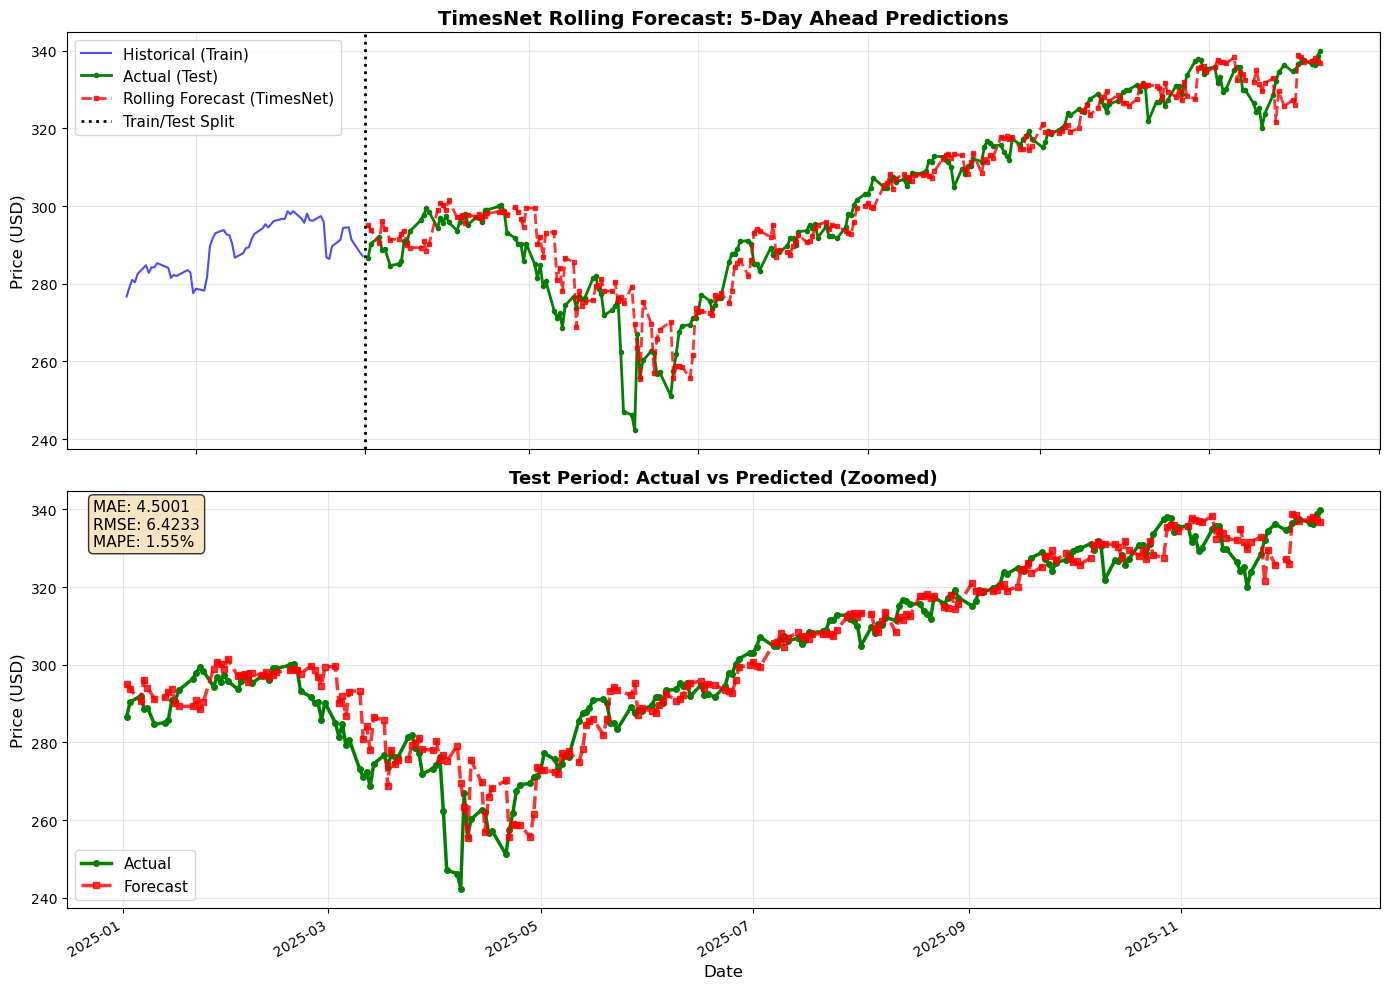

In [11]:
# График: скользящий прогноз vs реальная цена
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Полная картина с контекстом
ax1 = axes[0]

# Последние 60 дней train для контекста
last_60_days_train = df_train.tail(60)
ax1.plot(last_60_days_train['ds'], last_60_days_train['y'], 
        label='Historical (Train)', color='blue', linewidth=1.5, alpha=0.7)

# Реальные данные test
ax1.plot(results_df['ds'], results_df['actual'], 
        label='Actual (Test)', color='green', linewidth=2, marker='o', markersize=3)

# Прогноз
ax1.plot(results_df['ds'], results_df['predicted'], 
        label='Rolling Forecast (TimesNet)', color='red', linewidth=2, 
        linestyle='--', marker='s', markersize=3, alpha=0.8)

ax1.axvline(x=pd.to_datetime(split_date), color='black', 
           linestyle=':', linewidth=2, label='Train/Test Split')

ax1.legend(loc='best', fontsize=11)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.set_title(f'TimesNet Rolling Forecast: {horizon}-Day Ahead Predictions', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# График 2: Только тестовый период (zoom)
ax2 = axes[1]

ax2.plot(results_df['ds'], results_df['actual'], 
        label='Actual', color='green', linewidth=2.5, marker='o', markersize=4)

ax2.plot(results_df['ds'], results_df['predicted'], 
        label='Forecast', color='red', linewidth=2.5, 
        linestyle='--', marker='s', markersize=4, alpha=0.8)

ax2.legend(loc='best', fontsize=11)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Price (USD)', fontsize=12)
ax2.set_title('Test Period: Actual vs Predicted (Zoomed)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем текст с метриками
textstr = f'MAE: {mae_value:.4f}\nRMSE: {rmse_value:.4f}\nMAPE: {mape:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()